# MNIST Baseline Model

## Objective

In this notebook, we will establish a simple neural-network baseline for MNIST digit classification.

The baseline will use fully connected (`Linear`) layers without convolution.

The purpose of this model is not to achieve the best possible accuracy. Instead, it provides a reference point that we can later compare against more specialized image architectures.

## Workflow

1. Load and prepare MNIST
2. Create a simple fully connected neural network
3. Define the loss function and optimizer
4. Train the model
5. Evaluate its performance
6. Analyze its errors
7. Record conclusions for comparison with the future CNN

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device: ", device)

Using device:  cpu


Loading the dataset

In [8]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root = "../../data/raw",
    train = True,
    download = True,
    transform = transform
)

test_dataset = torchvision.datasets.MNIST(
    root = "../../data/raw",
    train = False,
    download = True,
    transform = transform
)

100.0%
100.0%
100.0%
100.0%


## Creating DataLoaders

A neural network is normally trained using mini-batches rather than processing the entire training dataset at once.

A `DataLoader` handles:

- grouping samples into batches
- shuffling the training data
- iterating over the dataset efficiently

We will initially use a batch size of 64.

In [9]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [10]:
images, labels = next(iter(train_loader))

print("Images shape: ", images.shape)
print("Labels shape: ", labels.shape)

Images shape:  torch.Size([64, 1, 28, 28])
Labels shape:  torch.Size([64])


## Baseline Architecture

The baseline model treats each image as a vector of 784 pixel values.

The model consists of:

- a flattening operation
- a fully connected layer from 784 to 128 features
- a ReLU activation
- a fully connected output layer from 128 to 10 classes

The ten output values correspond to the ten possible digits.

In [23]:
class BaseLineModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [24]:
blmodel = BaseLineModel().to(device)

print(blmodel)

BaseLineModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [25]:
total_params = sum(
    parameter.numel()
    for parameter in blmodel.parameters()
)

print(f"Total parameters: {total_params:,}")

Total parameters: 101,770


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    blmodel.parameters(),
    lr = 0.001
)

## Training Loop

After deciding what loss function and optimizer to use, we can start working on the training loop.
The fundamental training process is: images -> forward pass -> predictions -> calculate loss -> backpropagation -> calculate gradients -> optimizer updates weights -> repeat

In [27]:
epochs = 5

train_losses = []

for epoch in range(epochs):
    blmodel.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = blmodel(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{epochs}" f"- Loss: {epoch_loss:.4f}")

Epoch 1/5- Loss: 0.3491
Epoch 2/5- Loss: 0.1637
Epoch 3/5- Loss: 0.1151
Epoch 4/5- Loss: 0.0867
Epoch 5/5- Loss: 0.0692


([<matplotlib.axis.XTick at 0x20d997f8b30>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

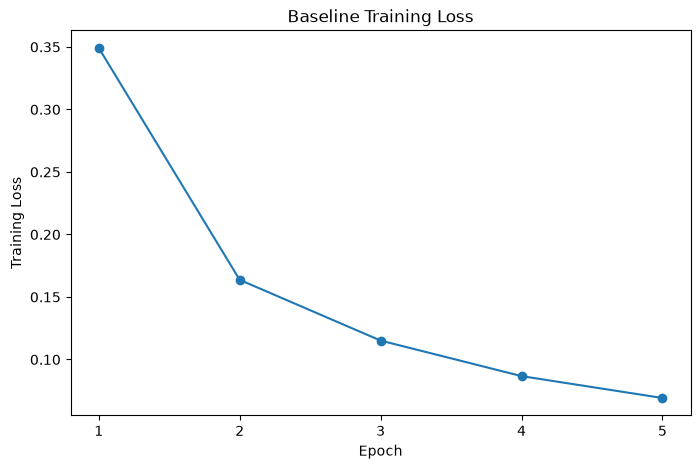

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker = "o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Training Loss")
plt.xticks(range(1, epochs + 1))

In [32]:
def evaluate(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim = 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    return correct / total

In [33]:
test_accuracy = evaluate(
    model = blmodel,
    dataloader = test_loader,
    device = device
)

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 97.04%


# Baseline Results

The fully connected baseline achieved a test accuracy of approximately **97.04%** after 5 training epochs.

The model contains **101,770 trainable parameters** and treats each 28 × 28 image as a flattened 784-dimensional vector.

Despite not explicitly modeling spatial relationships between neighboring pixels, the baseline achieves strong performance on MNIST.

However, the model discards the two-dimensional spatial structure of the image during flattening. This motivates testing whether a convolutional architecture can improve performance and/or parameter efficiency.

## Next Step

We will analyze the baseline's incorrect predictions before implementing a convolutional neural network.

## Error Analysis

Test accuracy gives us a high-level measure of model performance, but it does not tell us which examples the model gets wrong.

We will therefore inspect the model's predictions on the test set and investigate:

- how many predictions are incorrect
- which classes are most frequently confused
- examples of incorrect predictions
- whether the errors appear visually ambiguous

In [37]:
blmodel.eval()

all_predictions = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = blmodel(images)
        predictions = outputs.argmax(dim = 1)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels)
        all_images.append(images.cpu())

all_predictions = torch.cat(all_predictions)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)

print("Predictions: ", all_predictions.shape)
print("Labels: ", all_labels.shape)
print("Images: ", all_images.shape)

Predictions:  torch.Size([10000])
Labels:  torch.Size([10000])
Images:  torch.Size([10000, 1, 28, 28])


## Finding the incorrect predictions

In [44]:
incorrect_predictions = all_predictions != all_labels
incorrect_indices = torch.where(incorrect_predictions)[0]

print("Incorrect predictions: ", len(incorrect_indices))
print("Correct predictions: ", len(all_predictions) - len(incorrect_indices))

Incorrect predictions:  296
Correct predictions:  9704


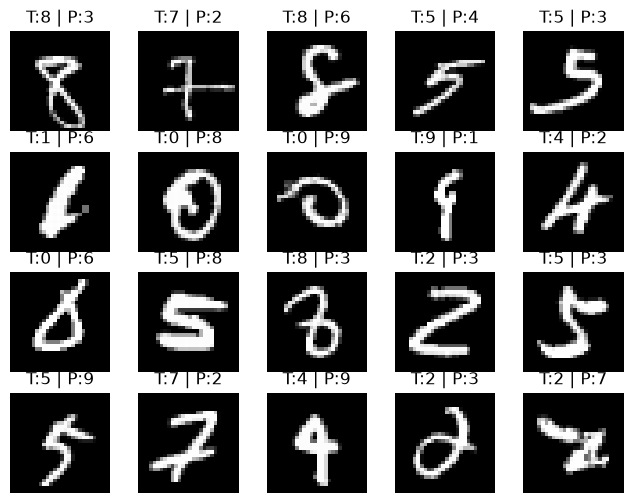

In [54]:
fig, axes = plt.subplots(4, 5, figsize=(8,6))

num_examples = 20

random_indices = incorrect_indices[torch.randperm(len(incorrect_indices))[:num_examples]]

for ax, index in zip(axes.flat, random_indices):
    image = all_images[index].squeeze()
    true_label = all_labels[index].item()
    predicted_label = all_predictions[index].item()

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"T:{true_label} | P:{predicted_label}"
    )
    ax.axis("off")

## Confusion Matrix

A confusion matrix shows how often examples from each true class are assigned to each predicted class.

Rows represent the true labels, while columns represent the model's predictions.

This allows us to identify systematic patterns in the model's mistakes rather than examining individual examples only.

Text(0.5, 1.0, 'Baseline model confusion matrix')

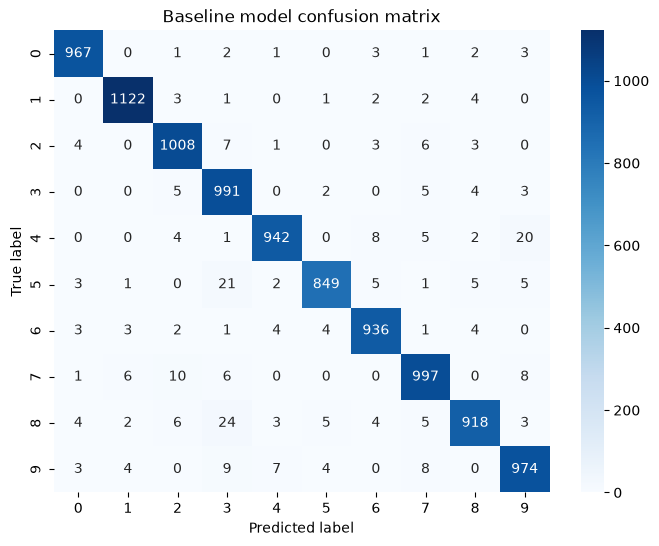

In [56]:
confusion_matrix = np.zeros((10,10), dtype=int)

for true_label, predicted_label in zip(all_labels.numpy(), all_predictions.numpy()):
    confusion_matrix[true_label, predicted_label] += 1

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Baseline model confusion matrix")

In [58]:
confusions = []

for true_label in range(10):
    for predicted_label in range(10):
        if true_label != predicted_label:
            count = confusion_matrix[true_label, predicted_label]
            confusions.append((count, true_label, predicted_label))

confusions.sort(reverse=True)

for count, true_label, predicted_label in confusions[:10]:
    print(
        f"True {true_label} -> Predicted {predicted_label}: {count} examples"
    )

True 8 -> Predicted 3: 24 examples
True 5 -> Predicted 3: 21 examples
True 4 -> Predicted 9: 20 examples
True 7 -> Predicted 2: 10 examples
True 9 -> Predicted 3: 9 examples
True 9 -> Predicted 7: 8 examples
True 7 -> Predicted 9: 8 examples
True 4 -> Predicted 6: 8 examples
True 9 -> Predicted 4: 7 examples
True 2 -> Predicted 3: 7 examples


In [60]:
true_digit = 8
predicted_digit = 3

pair_indices = torch.where((all_labels == true_digit) & (all_predictions == predicted_digit))[0]

Text(0.5, 0.98, '8 -> 3')

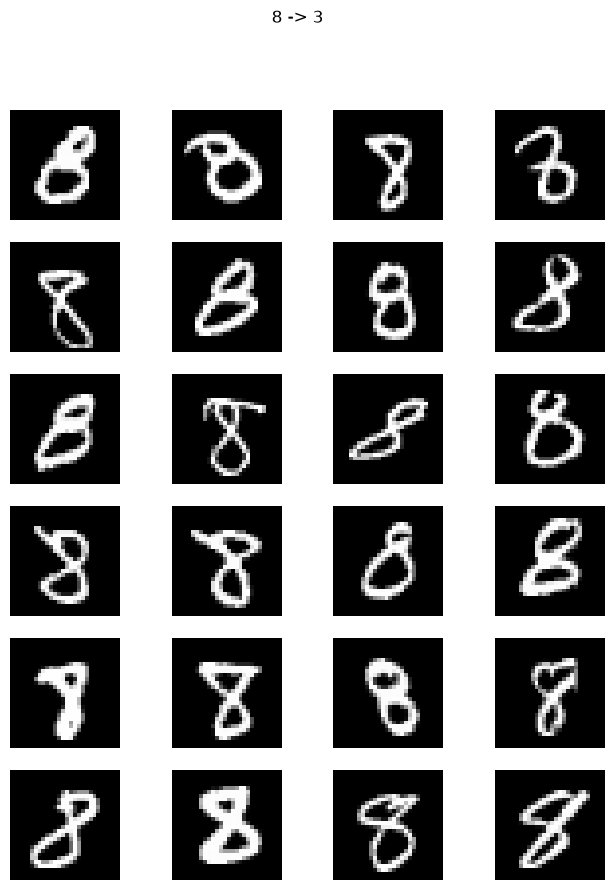

In [74]:
fig, axes = plt.subplots(6, 4, figsize=(8,10))

for ax, index in zip(axes.flat, pair_indices[:24]):
    image = all_images[index].squeeze()

    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.suptitle(f"{true_digit} -> {predicted_digit}")

## Confidence

Let's check the least confidence predictions of the model

The model outputs 10 logits, but those can be converted into probabilities with softmax.

In [75]:
sample_logits = []

blmodel.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = blmodel(images)

        sample_logits.append(outputs.cpu())

sample_logits = torch.cat(sample_logits)

probabilities = torch.softmax(sample_logits, dim = 1)

confidence, predictions = probabilities.max(dim = 1)

print("Average confidence: ", confidence.mean().item())
print("Maximum confidence: ", confidence.max().item())
print("Minimum confidence: ", confidence.min().item())

Average confidence:  0.9687690138816833
Maximum confidence:  1.0
Minimum confidence:  0.29036128520965576


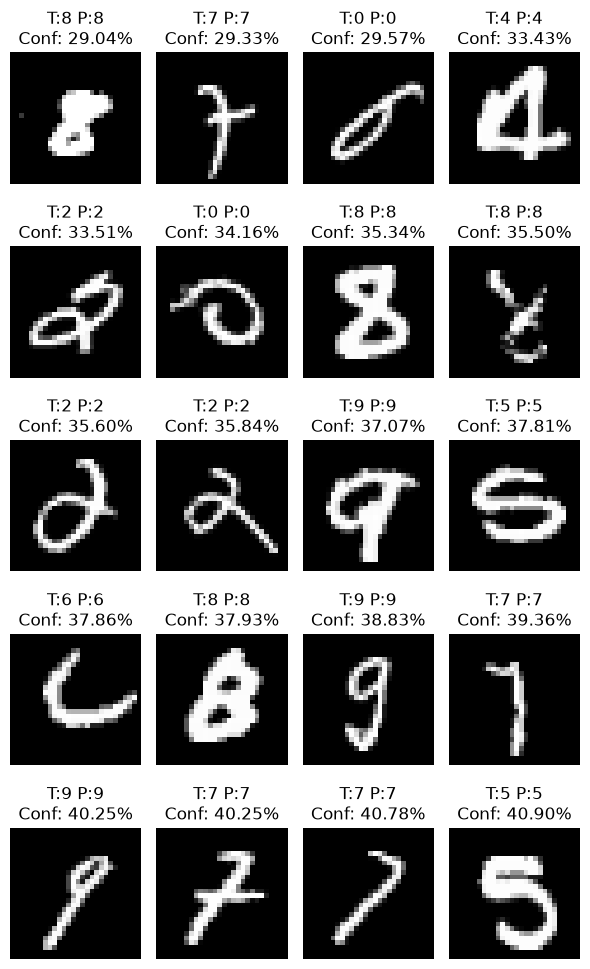

In [80]:
least_confident = torch.argsort(confidence)[:20]

fig, axes = plt.subplots(5,4, figsize=(6,10))

for ax, index in zip(axes.flat, least_confident):
    image = all_images[index].squeeze()

    true_label = all_labels[index].item()
    predicted_label = all_labels[index].item()
    conf = confidence[index].item()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"T:{true_label} P:{predicted_label}\nConf: {conf:.2%}")
    ax.axis("off")

plt.tight_layout()

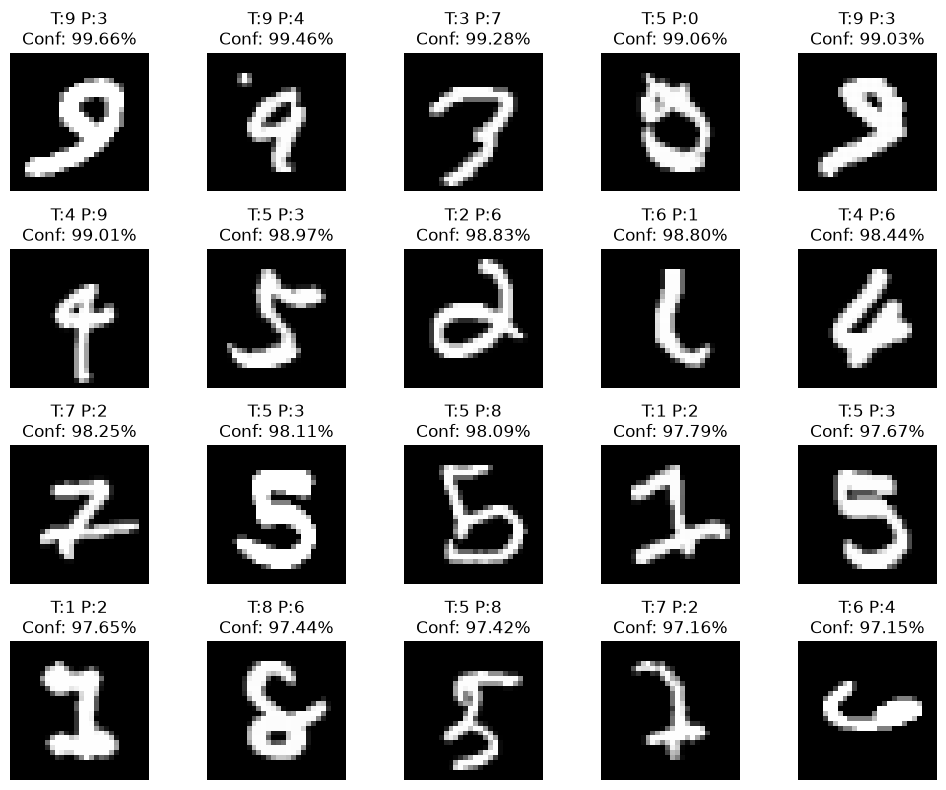

In [82]:
incorrect_confidence = confidence.clone()
incorrect_confidence[~incorrect_predictions] = -1

confident_mistakes = torch.argsort(incorrect_confidence, descending=True)[:20]

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for ax, index in zip(axes.flat, confident_mistakes):

    image = all_images[index].squeeze()

    true_label = all_labels[index].item()
    predicted_label = predictions[index].item()
    conf = confidence[index].item()

    ax.imshow(image, cmap="gray")

    ax.set_title(
        f"T:{true_label} P:{predicted_label}\n"
        f"Conf: {conf:.2%}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Error Analysis Summary

The baseline model achieves strong overall accuracy, but its remaining errors are not uniformly distributed across the ten classes.

The confusion matrix shows that certain pairs of digits are confused more frequently than others. Visual inspection of these examples shows that some errors correspond to genuinely ambiguous handwriting, while others appear to be mistakes on relatively recognizable examples.

The model's confidence also provides additional information beyond accuracy. Some incorrect predictions have relatively low confidence, suggesting uncertainty, while other incorrect predictions are made with high confidence.

The baseline treats each image as a flattened vector of 784 pixel values. Although the fully connected network can learn relationships between pixels, it does not explicitly exploit the local spatial structure of images.

This provides a strong motivation for the next phase: implementing a convolutional neural network and comparing its performance and behavior against the fully connected baseline.

## Baseline Reference

- Test accuracy: **97.04%**
- Number of test samples: **10,000**
- Number of incorrect predictions: **296**
- Trainable parameters: **101770**